<a href="https://colab.research.google.com/github/Ash100/MDS/blob/main/apo_simulation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install MDAnalysis and MDTraj
!pip install --quiet mdanalysis mdtraj freesasa

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import MDAnalysis as mda
from MDAnalysis.analysis import hydrogenbonds, dssp, pca
import mdtraj as md
import matplotlib.pyplot as plt
import numpy as np
from MDAnalysis.topology.guessers import guess_types

In [5]:
# 1. Define the missing radii for the ions (In Angstroms for MDAnalysis)
# Na: 2.27 A, Cl: 1.75 A
ion_radii = {'Na': 2.27, 'Cl': 1.75}

# UPDATE THESE PATHS
top_path = '/content/drive/MyDrive/Anwar_simulation/TCTP_equil.pdb'
traj_path = '/content/drive/MyDrive/Anwar_simulation/TCTP_prod1-5_whole.dcd'

# 3. Load Universe with the vdwradii keyword to satisfy the bond guesser
u = mda.Universe(top_path, traj_path,
                 guess_bonds=True,
                 vdwradii=ion_radii)

# 4. Add element information for H-bond detection
u.add_TopologyAttr('elements', guess_types(u.atoms.names))

# 5. Load for MDTraj (Note: MDTraj usually ignores the ions for these analyses)
t = md.load(traj_path, top=top_path)

print(f"Successfully loaded {len(u.trajectory)} frames of TCTP.")

/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/PDBParser.py:309: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/usr/local/lib/python3.12/dist-packages/MDAnalysis/core/universe.py:607: DeprecationWarning: Bond guessing through the `guess_bonds` keyword is deprecated and will be removed in MDAnalysis 3.0. Instead, pass 'bonds', 'angles', and 'dihedrals' to the `to_guess` keyword in Universe for guessing these if they are not present, or `fo

Successfully loaded 1000 frames of TCTP.


Starting H-bond analysis on 100 sampled frames...


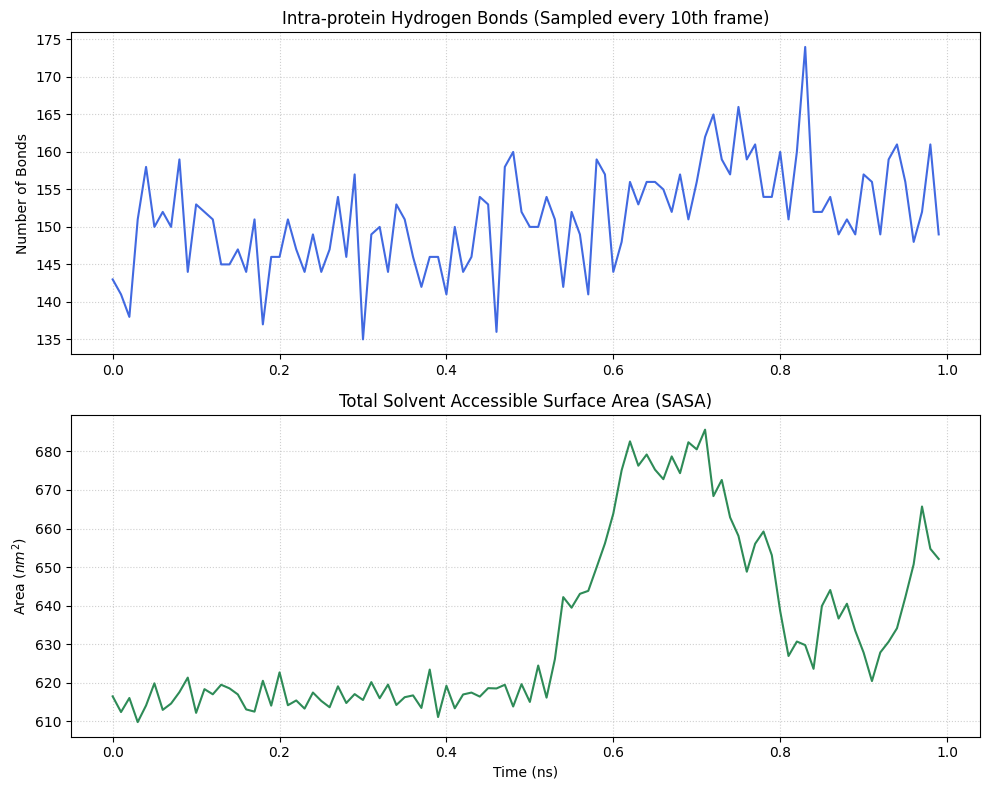

Analysis complete. Sampled 100 frames.


In [6]:
# --- 1. Fast Hydrogen Bond Analysis (Strided) ---
# We sample every 10th frame (stride=10) to speed this up significantly.
# For 100ns, 10% of frames is more than enough to see the trend.
stride = 10
t_sub = t[::stride]

hb_count = []
print(f"Starting H-bond analysis on {len(t_sub)} sampled frames...")

for frame in range(len(t_sub)):
    # baker_hubbard is robust but slow in a loop; striding is the solution
    frame_hbonds = md.baker_hubbard(t_sub[frame], periodic=False)
    hb_count.append(len(frame_hbonds))

# --- 2. SASA Analysis (Already fast, but kept for consistency) ---
custom_radii = {"Na": 0.227, "Cl": 0.175}
sasa_all = md.shrake_rupley(t_sub, mode='atom', change_radii=custom_radii)
total_sasa = sasa_all.sum(axis=1)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# H-Bonds Plot (Adjust X-axis to reflect time)
time_ns = t_sub.time / 1000
ax1.plot(time_ns, hb_count, color='royalblue', linewidth=1.5)
ax1.set_title('Intra-protein Hydrogen Bonds (Sampled every 10th frame)')
ax1.set_ylabel('Number of Bonds')
ax1.grid(True, linestyle=':', alpha=0.6)

# SASA Plot
ax2.plot(time_ns, total_sasa, color='seagreen', linewidth=1.5)
ax2.set_title('Total Solvent Accessible Surface Area (SASA)')
ax2.set_xlabel('Time (ns)')
ax2.set_ylabel('Area ($nm^2$)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('tctp_fast_analysis.png', dpi=600)
plt.show()

print(f"Analysis complete. Sampled {len(t_sub)} frames.")

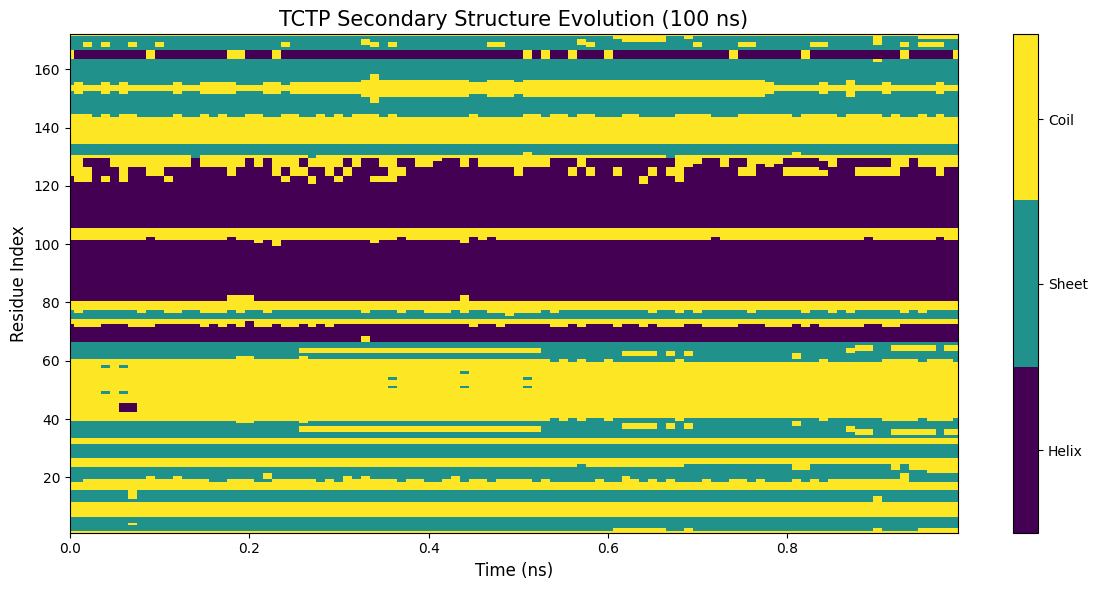

Plot generated for 172 residues across 1.0 ns.


In [13]:
# 1. Selection Step: Filter for protein only to fix the Y-axis
protein_indices = t_sub.topology.select('protein')
t_protein = t_sub.atom_slice(protein_indices)

# 2. Compute DSSP on only the protein
dssp_data = md.compute_dssp(t_protein, simplified=True)

# 3. Mapping with 'NA' handling
def map_dssp(res):
    mapping = {'H': 1, 'E': 2, 'C': 3}
    return mapping.get(res, 3)

dssp_numeric = np.array([[map_dssp(res) for res in frame] for frame in dssp_data])

# 4. Final Visualization
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(12, 6))

# Define clean axes
time_ns = t_protein.time / 1000
residues = np.arange(1, dssp_numeric.shape[1] + 1)

# pcolormesh is used to ensure the data fills the entire plot area
cmap = mcolors.ListedColormap(['#440154', '#21918c', '#fde725'])
mesh = ax.pcolormesh(time_ns, residues, dssp_numeric.T, shading='nearest', cmap=cmap)

# 5. Styling and Labels
ax.set_title('TCTP Secondary Structure Evolution (100 ns)', fontsize=15)
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('Residue Index', fontsize=12)

# Set the limits manually to prevent the "sliver" effect
ax.set_xlim(0, time_ns.max())
ax.set_ylim(1, residues.max())

# Custom colorbar
cbar = fig.colorbar(mesh, ax=ax, ticks=[1.33, 2, 2.66])
cbar.ax.set_yticklabels(['Helix', 'Sheet', 'Coil'])

# Vertical lines for your transition points
ax.axvline(x=50, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=85, color='white', linestyle='--', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig('tctp_dssp_fixed_final.png', dpi=600)
plt.show()

print(f"Plot generated for {dssp_numeric.shape[1]} residues across {time_ns.max():.1f} ns.")

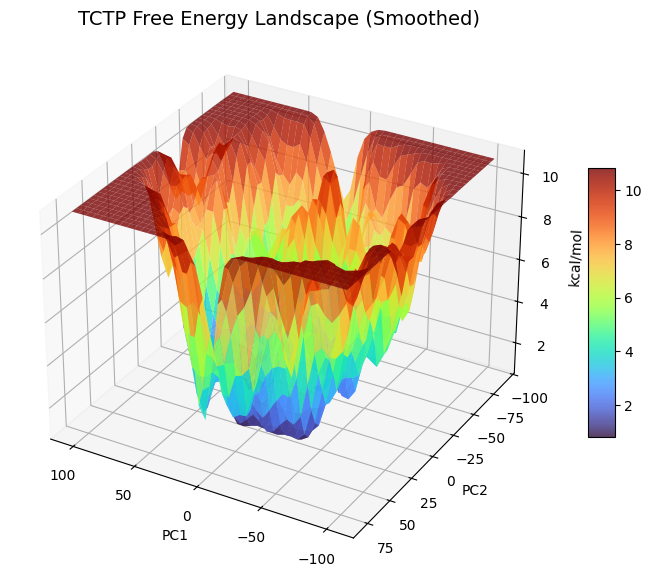

In [19]:
from scipy.ndimage import gaussian_filter

# 1. PCA Calculation
# Using the Universe 'u' from your earlier loading block
pc_calc = pca.PCA(u, select='backbone').run()
# Use 'transform' instead of 'projection' to avoid AttributeError
projs = pc_calc.transform(u.select_atoms('backbone'))
pc1, pc2 = projs[:, 0], projs[:, 1]

# 2. Gibbs Free Energy Surface
kb, T = 0.001987, 300
counts, x_edges, y_edges = np.histogram2d(pc1, pc2, bins=40) # Slightly fewer bins for smoothness
prob = counts / np.sum(counts)
energy = -kb * T * np.log(prob + 1e-10)
energy -= energy.min()

# 3. Smoothing the Surface (Removes the 'spikes' seen in your image)
energy_smooth = gaussian_filter(energy, sigma=1.0)

# 4. 3D Plotting
X, Y = np.meshgrid(0.5*(x_edges[1:]+x_edges[:-1]), 0.5*(y_edges[1:]+y_edges[:-1]))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, energy_smooth.T, cmap='turbo', edgecolor='none', alpha=0.8)

ax.set_title('TCTP Free Energy Landscape (Smoothed)', fontsize=14)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('kcal/mol')
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.view_init(elev=30, azim=120)
plt.savefig('tctp_free_energy_landscape.png', dpi=600)

plt.show()